# Abacus gg/profile consistency tests

This notebook isolates why the pasted-map galaxy autopower can disagree with GODMAX theory even when galaxy cross-correlations with `y`, `tau`, and lensing look closer.  The diagnostics are ordered from low-level checks to final angular spectra: window/n(z), HMF/HOD, satellite/profile stacks, `Cl_gg`, and pixel-window/shot-noise tests.

All existing Abacus and pasted products are read-only.  Any cache or plot output should stay under `notebooks/xDESI/outputs/abacus_gg_profile_tests`.


In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

from pathlib import Path
import copy
import gc
import math
import time

import h5py
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

XDESI_DIR = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI')
import sys
if str(XDESI_DIR) not in sys.path:
    sys.path.insert(0, str(XDESI_DIR))

import abacus_pasting_helpers as aph
import abacus_particle_shell_helpers as psh
import abacus_gg_profile_helpers as agh

CONFIG = XDESI_DIR / 'abacus_pasting_config.yaml'
CATALOG = 'zlt0p5_logMgt14p0'
NSIDE = 1024
COMPARE_BIN = 0

ELL_MIN = 10
ELL_MAX = 3000
DELTA_ELL = 20
SMALL_SCALE_ELL_RANGE = (700, 2500)

THEORY_VARIANTS_TO_BUILD = ['fit_nz_current', 'tophat_hard_selection', 'measured_hard_selection']
BUILD_SYMBOLIC_FIT_THEORY = True
BUILD_WL_THEORY = True
RUN_SYNTHETIC_PAINT = False
RUN_RANDOM_PIXEL_TEST = True
RANDOM_POISSON_REALIZATIONS = 3
RANDOM_TEST_NSIDE = min(NSIDE, 512)

MAX_STACK_HALOS = 250
PROFILE_RADIAL_EDGES_R200 = np.linspace(0.0, 3.0, 31)
MASS_BINS = [(14.0, 14.25), (14.25, 14.5), (14.5, 15.0), (15.0, 16.0)]
Z_CENTERS = [0.2, 0.3, 0.4, 0.48]
Z_HALF_WIDTH = 0.04

cfg = aph.load_config(CONFIG)
CACHE_ROOT = Path(cfg['project']['output_root']).expanduser().resolve() / 'abacus_gg_profile_tests'
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
print('cache/output root:', CACHE_ROOT)


cache/output root: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/outputs/abacus_gg_profile_tests


## Load pasted map, generated galaxies, halo catalog, and fitted lens n(z)

The first comparison bin is the same bin currently used in the shell residual notebook.  The hard cut below is the map estimator selection; the GODMAX theory uses the full fitted lens n(z), so the next section tests that mismatch directly.


In [2]:
map_path = aph.final_map_path(cfg, CATALOG, NSIDE)
if not map_path.exists():
    raise FileNotFoundError(f'Missing pasted map: {map_path}')

maps_pasted, galaxies, map_attrs = aph.load_maps_h5(map_path)
halo_catalog, halo_attrs = aph.load_halo_catalog(aph.catalog_path(cfg, CATALOG))
nz_info, z_grid_lens, nbar_array_input = aph.load_xdesi_fit_lens_info(cfg)

z_edges = np.asarray(nz_info['z_edges_bins_lens'], dtype=np.float64)
z_range = tuple(z_edges[COMPARE_BIN])
z_mean_hard = 0.5 * (z_range[0] + z_range[1])
fit_nz = agh.normalize_nz(z_grid_lens, np.asarray(nz_info[f'nz{COMPARE_BIN}'], dtype=np.float64))
fit_nz_mean = float(np.trapz(z_grid_lens * fit_nz, z_grid_lens))

print('map:', map_path)
print('maps:', sorted(maps_pasted))
print('halos:', len(halo_catalog['z']), 'galaxies:', len(galaxies))
print('catalog z range:', float(np.min(halo_catalog['z'])), float(np.max(halo_catalog['z'])))
print('catalog logM range:', float(np.min(halo_catalog['log10M200c_hMsun'])), float(np.max(halo_catalog['log10M200c_hMsun'])))
print('comparison bin:', COMPARE_BIN, 'hard z_range:', z_range, 'fit nz mean:', fit_nz_mean)
print('map attrs:', {k: map_attrs[k] for k in ['nside', 'n_galaxies', 'catalog_key'] if k in map_attrs})


map: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/outputs/abacus_maps/abacus_c9999_ph9999_xdesi/abacus_pasted_maps_zlt0p5_logMgt14p0_nside1024.h5
maps: ['map_kappa_cmb', 'map_kappa_wl', 'map_ksz', 'map_rhom', 'map_rhom_dmb', 'map_rhom_dmo', 'map_tau', 'map_ymap']
halos: 140661 galaxies: 223411
catalog z range: 0.005598946940153837 0.4999968409538269
catalog logM range: 14.000000953674316 15.586517333984375
comparison bin: 0 hard z_range: (0.2741959798994975, 0.4268643216080403) fit nz mean: 0.3595293775603623
map attrs: {'nside': 1024, 'n_galaxies': 223411, 'catalog_key': 'zlt0p5_logMgt14p0'}


## Window and n(z) checks

This cell measures the actual generated galaxy redshift distribution and constructs the alternative n(z) choices used later in theory.  The important distinction is:

- `fit_nz_current`: the original fitted Abacus LRG n(z) used by GODMAX theory.
- `tophat_hard_selection`: a top-hat matching the current map selection.
- `measured_hard_selection`: the actual generated galaxy dN/dz after the same hard selection.


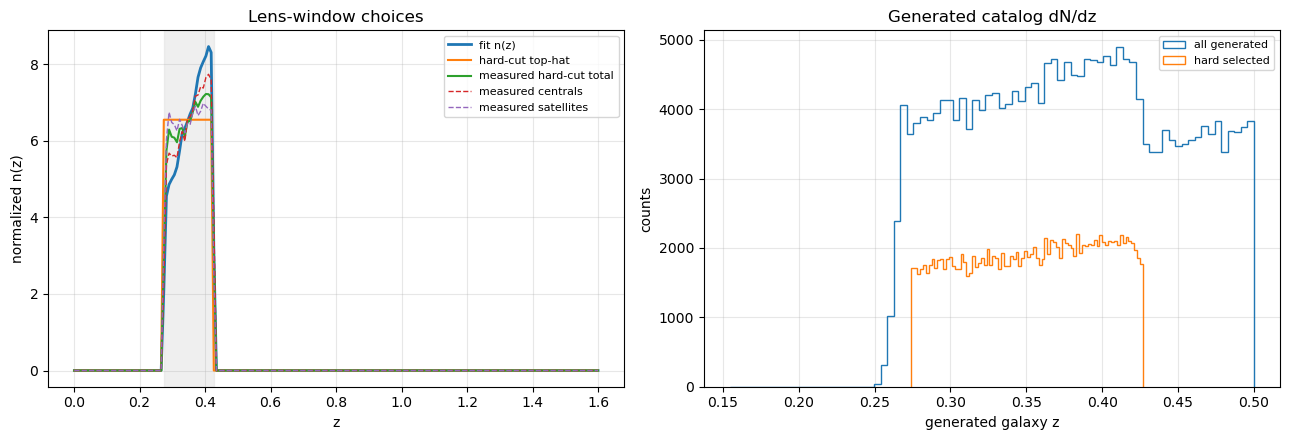

,sample,count,z_mean
0,all generated,223411,0.379613
1,hard selected total,152180,0.353323
2,hard selected centrals,64858,0.356280
3,hard selected satellites,87322,0.351126
4,fit reweight nonzero,223411,0.358841


fit reweight: min/max/sumw/sumw2 = 0.00025560677267721563 3.2502434457022287 223602.39549175356 324973.46958986233


In [3]:
tophat_nz = agh.make_tophat_nz(z_grid_lens, z_range)
measured_all = agh.measured_galaxy_nz(galaxies, z_grid_lens)
measured_hard = agh.measured_galaxy_nz(galaxies, z_grid_lens, z_range=z_range)
measured_hard_cen = agh.measured_galaxy_nz(galaxies, z_grid_lens, z_range=z_range, central_flag=True)
measured_hard_sat = agh.measured_galaxy_nz(galaxies, z_grid_lens, z_range=z_range, central_flag=False)
fit_reweight = agh.reweight_to_target_nz(galaxies, z_grid_lens, fit_nz, max_weight=20.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(z_grid_lens, fit_nz, lw=2, label='fit n(z)')
ax.plot(z_grid_lens, tophat_nz, lw=1.5, label='hard-cut top-hat')
ax.plot(z_grid_lens, measured_hard['nz'], lw=1.5, label='measured hard-cut total')
ax.plot(z_grid_lens, measured_hard_cen['nz'], lw=1.0, ls='--', label='measured centrals')
ax.plot(z_grid_lens, measured_hard_sat['nz'], lw=1.0, ls='--', label='measured satellites')
ax.axvspan(z_range[0], z_range[1], color='0.85', alpha=0.4)
ax.set_xlabel('z')
ax.set_ylabel('normalized n(z)')
ax.set_title('Lens-window choices')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
valid = galaxies[:, 5] > 0.5
ax.hist(galaxies[valid, 2], bins=80, histtype='step', label='all generated')
sel = valid & (galaxies[:, 2] >= z_range[0]) & (galaxies[:, 2] < z_range[1])
ax.hist(galaxies[sel, 2], bins=80, histtype='step', label='hard selected')
ax.set_xlabel('generated galaxy z')
ax.set_ylabel('counts')
ax.set_title('Generated catalog dN/dz')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

dnz_summary = pd.DataFrame([
    {'sample': 'all generated', 'count': measured_all['count'], 'z_mean': float(np.trapz(z_grid_lens * measured_all['nz'], z_grid_lens))},
    {'sample': 'hard selected total', 'count': measured_hard['count'], 'z_mean': float(np.trapz(z_grid_lens * measured_hard['nz'], z_grid_lens))},
    {'sample': 'hard selected centrals', 'count': measured_hard_cen['count'], 'z_mean': float(np.trapz(z_grid_lens * measured_hard_cen['nz'], z_grid_lens))},
    {'sample': 'hard selected satellites', 'count': measured_hard_sat['count'], 'z_mean': float(np.trapz(z_grid_lens * measured_hard_sat['nz'], z_grid_lens))},
    {'sample': 'fit reweight nonzero', 'count': int(np.count_nonzero(fit_reweight > 0)), 'z_mean': float(np.average(galaxies[fit_reweight > 0, 2], weights=fit_reweight[fit_reweight > 0]))},
])
display(dnz_summary)
print('fit reweight: min/max/sumw/sumw2 =', float(np.min(fit_reweight)), float(np.max(fit_reweight)), float(np.sum(fit_reweight)), float(np.sum(fit_reweight**2)))


## Build theory variants

This builds the current GODMAX theory and two window-matched variants.  It also builds the original-fit style symbolic PK/HMF theory for the fitted n(z), because the HOD parameters were fit in that mode in `test_fit_abacus.ipynb`.


In [4]:
lens_info_fit = copy.deepcopy(nz_info)
lens_info_tophat = agh.clone_lens_info_with_bin(nz_info, COMPARE_BIN, z_grid_lens, tophat_nz, z_edges=np.asarray(z_range), floor=0.0)
lens_info_measured = agh.clone_lens_info_with_bin(nz_info, COMPARE_BIN, z_grid_lens, measured_hard['nz'], z_edges=np.asarray(z_range), floor=0.0)

lens_info_by_name = {
    'fit_nz_current': lens_info_fit,
    'tophat_hard_selection': lens_info_tophat,
    'measured_hard_selection': lens_info_measured,
}
nz_mean_by_name = {
    'fit_nz_current': fit_nz_mean,
    'tophat_hard_selection': z_mean_hard,
    'measured_hard_selection': float(np.trapz(z_grid_lens * measured_hard['nz'], z_grid_lens)),
}

theory_bundles = {}
theory_curves = {}
for name in THEORY_VARIANTS_TO_BUILD:
    t0 = time.perf_counter()
    print(f'building theory: {name} symbolic=False')
    cmb = agh.build_theory_bundle(CONFIG, CATALOG, name=f'{name}_cmb', lens_info=lens_info_by_name[name], is_cmb_lensing=True, symbolic=False, z_max=0.5, log10_mass_min=14.0)
    wl = None
    if BUILD_WL_THEORY:
        wl = agh.build_theory_bundle(CONFIG, CATALOG, name=f'{name}_wl', lens_info=lens_info_by_name[name], is_cmb_lensing=False, symbolic=False, z_max=0.5, log10_mass_min=14.0)
    key = f'{name}_nonsymbolic'
    theory_bundles[key] = {'cmb': cmb, 'wl': wl}
    theory_curves[key] = agh.extract_theory_curves(cmb, wl, COMPARE_BIN, nz_mean_by_name[name])
    print(f'  done in {time.perf_counter() - t0:.1f}s')
    gc.collect()

if BUILD_SYMBOLIC_FIT_THEORY:
    t0 = time.perf_counter()
    print('building theory: fit_nz_current symbolic=True')
    cmb = agh.build_theory_bundle(CONFIG, CATALOG, name='fit_nz_current_cmb_symbolic', lens_info=lens_info_fit, is_cmb_lensing=True, symbolic=True, z_max=0.5, log10_mass_min=14.0)
    wl = None
    if BUILD_WL_THEORY:
        wl = agh.build_theory_bundle(CONFIG, CATALOG, name='fit_nz_current_wl_symbolic', lens_info=lens_info_fit, is_cmb_lensing=False, symbolic=True, z_max=0.5, log10_mass_min=14.0)
    theory_bundles['fit_nz_current_symbolic'] = {'cmb': cmb, 'wl': wl}
    theory_curves['fit_nz_current_symbolic'] = agh.extract_theory_curves(cmb, wl, COMPARE_BIN, fit_nz_mean)
    print(f'  done in {time.perf_counter() - t0:.1f}s')
    gc.collect()

display(pd.DataFrame([{'theory': k, 'nell': len(v['ell']), 'ell_min': v['ell'][0], 'ell_max': v['ell'][-1]} for k, v in theory_curves.items()]))


building theory: fit_nz_current symbolic=False


E0601 17:10:48.899965 1182475 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.5.82, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


  done in 55.4s
building theory: tophat_hard_selection symbolic=False
  done in 30.3s
building theory: measured_hard_selection symbolic=False
  done in 30.8s
building theory: fit_nz_current symbolic=True
  done in 28.3s


,theory,nell,ell_min,ell_max
0,fit_nz_current_nonsymbolic,62,20.832871,2742.244598
1,tophat_hard_selection_nonsymbolic,62,20.832871,2742.244598
2,measured_hard_selection_nonsymbolic,62,20.832871,2742.244598
3,fit_nz_current_symbolic,62,20.832871,2742.244598


## Theory lens-window inspection

This verifies that the theory objects actually use the intended galaxy window.  If `gg` changes mainly under these window substitutions, the problem is not in the map painter but in comparing a hard-cut map to an extended n(z) theory.


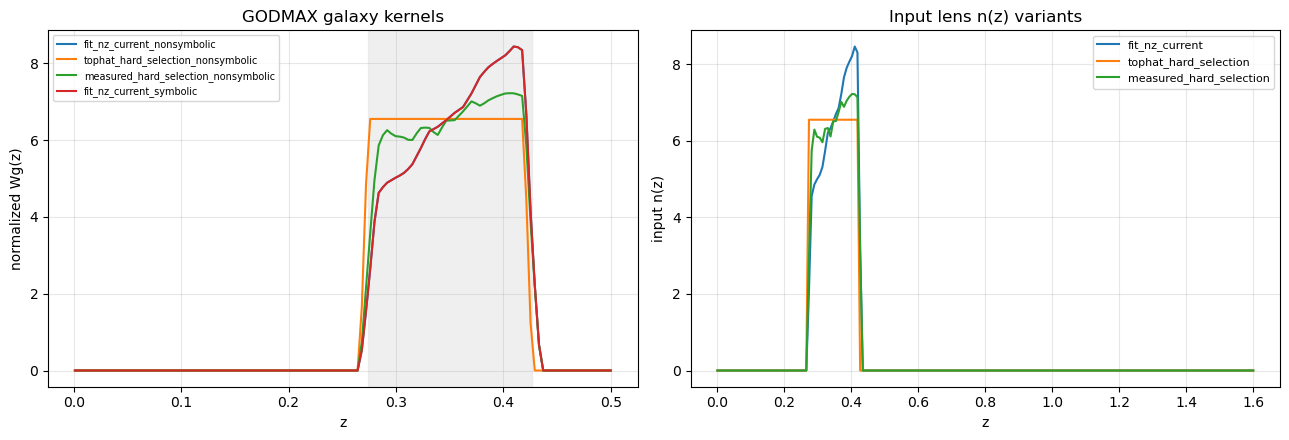

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for key, bundles in theory_bundles.items():
    cls = bundles['cmb'].cls
    z_cls = np.asarray(cls.z_array_for_Cls)
    wg = np.squeeze(np.asarray(cls.Wg_mat[COMPARE_BIN], dtype=np.float64))
    wg_norm = wg / np.trapz(wg, z_cls) if np.trapz(wg, z_cls) != 0 else wg
    axes[0].plot(z_cls, wg_norm, label=key)
axes[0].axvspan(z_range[0], z_range[1], color='0.85', alpha=0.4)
axes[0].set_xlabel('z')
axes[0].set_ylabel('normalized Wg(z)')
axes[0].set_title('GODMAX galaxy kernels')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7)

for name, info in lens_info_by_name.items():
    axes[1].plot(z_grid_lens, agh.normalize_nz(z_grid_lens, info[f'nz{COMPARE_BIN}']), label=name)
axes[1].set_xlabel('z')
axes[1].set_ylabel('input n(z)')
axes[1].set_title('Input lens n(z) variants')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## HMF, HOD, and satellite truncation checks

These checks compare the finite Abacus high-mass catalog to the halo-model mass function and compare actual generated central/satellite counts to the summed GODMAX HOD expectations over the same halos.  The HMF comparison is approximate because it uses a full-sky volume inferred from the catalog sky coverage.


,nside,n_occupied,npix,fsky_occupied
0,4,192,192,1.000000
1,8,768,768,1.000000
2,16,3072,3072,1.000000
3,32,12287,12288,0.999919
4,64,44838,49152,0.912231


HMF comparison fsky: 1.0


,z_lo,z_hi,logM_lo,logM_hi,observed,expected,obs_over_exp
0,0.00,0.15,14.00,14.25,4957.0,4631.866764,1.070195
1,0.00,0.15,14.25,14.50,1989.0,1937.141079,1.026771
2,0.00,0.15,14.50,15.00,847.0,842.522477,1.005314
3,0.00,0.15,15.00,16.00,37.0,36.482468,1.014186
4,0.15,0.25,14.00,14.25,13931.0,14312.536804,0.973342
5,0.15,0.25,14.25,14.50,5284.0,5695.301282,0.927782
6,0.15,0.25,14.50,15.00,2127.0,2264.412554,0.939316
7,0.15,0.25,15.00,16.00,92.0,78.407769,1.173353
8,0.25,0.35,14.00,14.25,24109.0,26214.386651,0.919686
9,0.25,0.35,14.25,14.50,8736.0,9939.762923,0.878894


,z_lo,z_hi,logM_lo,logM_hi,n_halos,actual_cen,pred_cen,actual_sat,pred_sat,actual_tot,pred_tot,cen_over_pred,sat_over_pred,tot_over_pred
0,0.00,0.15,14.00,14.25,4957,0,0.418643,0,0.000000,0,0.418643,0.000000,NaN,0.000000
1,0.00,0.15,14.25,14.50,1989,0,0.318151,0,0.000000,0,0.318151,0.000000,NaN,0.000000
2,0.00,0.15,14.50,15.00,847,0,0.256668,0,0.000000,0,0.256668,0.000000,NaN,0.000000
3,0.00,0.15,15.00,16.00,37,0,0.027071,0,0.000000,0,0.027071,0.000000,NaN,0.000000
4,0.15,0.25,14.00,14.25,13931,1,15.780337,0,0.090083,1,15.870420,0.063370,0.000000,0.063010
5,0.15,0.25,14.25,14.50,5284,1,8.054266,0,0.514645,1,8.568911,0.124158,0.000000,0.116701
6,0.15,0.25,14.50,15.00,2127,1,4.907199,0,3.227927,1,8.135127,0.203782,0.000000,0.122924
7,0.15,0.25,15.00,16.00,92,0,0.315060,0,1.496348,0,1.811408,0.000000,0.000000,0.000000
8,0.25,0.35,14.00,14.25,24109,20401,18659.575246,16233,17176.412466,36634,35835.987712,1.093326,0.945075,1.022268
9,0.25,0.35,14.25,14.50,8736,7435,7424.663904,16268,17094.208839,23703,24518.872743,1.001392,0.951667,0.966725


{'max_mean_nsat': 609.983127057973, 'max_gals_per_halo': 637, 'max_tail_probability': 0.14170020628000618, 'mean_tail_probability': 0.00022569178683404053}


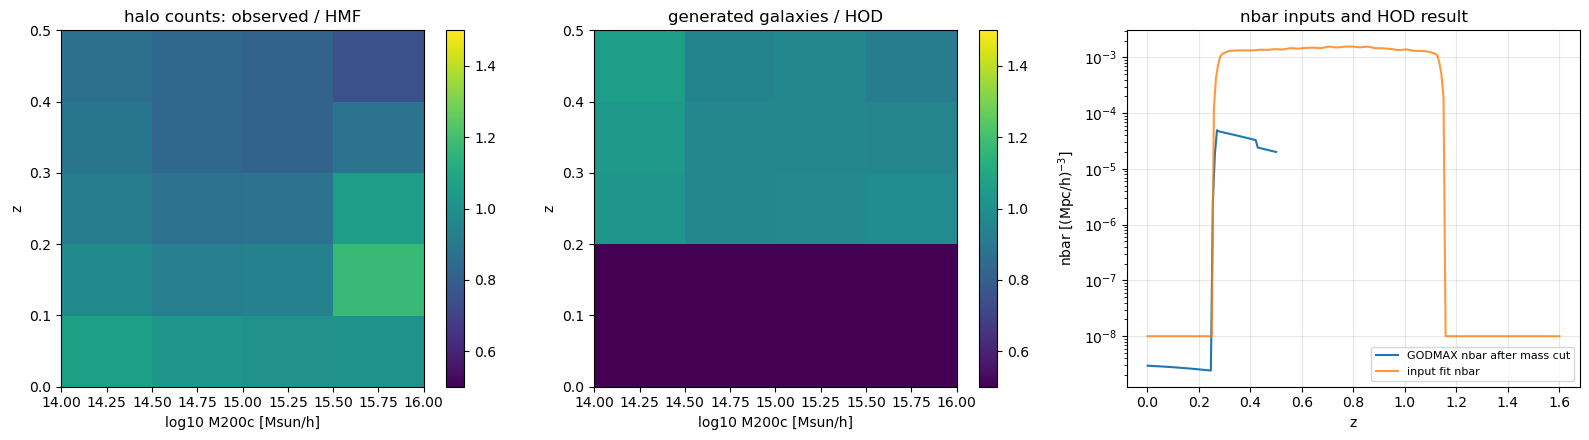

In [6]:
CURRENT_KEY = 'fit_nz_current_nonsymbolic'
model_ref = theory_bundles[CURRENT_KEY]['cmb']

z_edges_diag = np.array([0.0, 0.15, 0.25, 0.35, 0.45, 0.5])
logm_edges_diag = np.array([14.0, 14.25, 14.5, 15.0, 16.0])

sky_coverage_df = pd.DataFrame(agh.sky_coverage_by_nside(halo_catalog['ra_deg'], halo_catalog['dec_deg'], nsides=(4, 8, 16, 32, 64)))
display(sky_coverage_df)

# Abacus Backlight lightcone products are treated as full-sky here.  The occupied-pixel
# fsky table above is diagnostic only and is biased low for sparse high-mass halos.
HMF_FSKY = 1.0
hmf_cmp = agh.hmf_count_comparison(halo_catalog, model_ref, z_edges=z_edges_diag, logm_edges=logm_edges_diag, fsky=HMF_FSKY)
hmf_df = pd.DataFrame(hmf_cmp['rows'])
print('HMF comparison fsky:', HMF_FSKY)
display(hmf_df)

hod_rows = agh.hod_occupation_comparison(halo_catalog, galaxies, model_ref, z_edges=z_edges_diag, logm_edges=logm_edges_diag)
hod_df = pd.DataFrame(hod_rows)
display(hod_df)

trunc = agh.satellite_truncation_summary(model_ref)
print({k: v for k, v in trunc.items() if k != 'tail_grid'})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
obs_exp = hmf_cmp['observed'] / np.maximum(hmf_cmp['expected'], 1.0e-30)
im = axes[0].imshow(obs_exp, origin='lower', aspect='auto', vmin=0.5, vmax=1.5, extent=[logm_edges_diag[0], logm_edges_diag[-1], z_edges_diag[0], z_edges_diag[-1]])
axes[0].set_title('halo counts: observed / HMF')
axes[0].set_xlabel('log10 M200c [Msun/h]')
axes[0].set_ylabel('z')
plt.colorbar(im, ax=axes[0])

pivot_tot = hod_df.pivot_table(index='z_lo', columns='logM_lo', values='tot_over_pred')
im = axes[1].imshow(pivot_tot.values, origin='lower', aspect='auto', vmin=0.5, vmax=1.5, extent=[logm_edges_diag[0], logm_edges_diag[-1], z_edges_diag[0], z_edges_diag[-1]])
axes[1].set_title('generated galaxies / HOD')
axes[1].set_xlabel('log10 M200c [Msun/h]')
axes[1].set_ylabel('z')
plt.colorbar(im, ax=axes[1])

z_model = np.asarray(model_ref.base.z_array)
axes[2].plot(z_model, np.asarray(model_ref.pkz.nbarz), label='GODMAX nbar after mass cut')
axes[2].plot(np.asarray(model_ref.analysis['nbar_gal_comoving_zarray']), np.asarray(model_ref.analysis['nbar_gal_comoving_val']), label='input fit nbar', alpha=0.8)
axes[2].set_yscale('log')
axes[2].set_xlabel('z')
axes[2].set_ylabel(r'nbar [(Mpc/h)$^{-3}$]')
axes[2].set_title('nbar inputs and HOD result')
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()


## HOD one-halo pair-count diagnostic

`C_ell^gg` is sensitive to second moments, not just mean galaxy counts.  This diagnostic compares realized one-halo pair moments in the pasted galaxy catalog against the moments used by the GODMAX one-halo `Pgg` model:

- central-satellite ordered pairs: `2 * ncen * nsat` vs `2 * <Ncen> * <Nsat>`
- satellite-satellite ordered pairs: `nsat * (nsat - 1)` vs `<Nsat>^2`

If these ratios are above unity by ~30-40% in the relevant redshift/mass bins, the remaining `gg` excess is coming from pair statistics rather than HMF, n(z), or shot-noise handling.


,z_lo,z_hi,logM_lo,logM_hi,n_halos,actual_cen,actual_sat,pred_cen,pred_sat,actual_cs_ordered,...,actual_ss_ordered,pred_ss_poisson_ordered,pred_ss_same_gal_included,actual_pair_total,pred_pair_total_poisson,pred_pair_total_same_gal_included,cs_over_pred,ss_over_pred_poisson,pair_over_pred_poisson,pair_over_pred_same_gal_included
0,0.00,0.15,14.00,14.25,4957,0,0,0.418643,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
1,0.00,0.15,14.25,14.50,1989,0,0,0.318151,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
2,0.00,0.15,14.50,15.00,847,0,0,0.256668,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
3,0.00,0.15,15.00,16.00,37,0,0,0.027071,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
4,0.15,0.25,14.00,14.25,13931,1,0,15.780337,0.090083,0.0,...,0.0,0.000038,0.090121,0.0,0.006432,0.096515,0.000000,0.000000,0.000000,0.000000
5,0.15,0.25,14.25,14.50,5284,1,0,8.054266,0.514645,0.0,...,0.0,0.002882,0.517526,0.0,0.048425,0.563070,0.000000,0.000000,0.000000,0.000000
6,0.15,0.25,14.50,15.00,2127,1,0,4.907199,3.227927,0.0,...,0.0,0.264084,3.492011,0.0,0.642367,3.870294,0.000000,0.000000,0.000000,0.000000
7,0.15,0.25,15.00,16.00,92,0,0,0.315060,1.496348,0.0,...,0.0,0.750251,2.246598,0.0,0.997384,2.493732,0.000000,0.000000,0.000000,0.000000
8,0.25,0.35,14.00,14.25,24109,20401,16233,18659.575246,17176.412466,29616.0,...,14028.0,15427.940137,32604.352602,43644.0,45064.298332,62240.710798,0.999313,0.909259,0.968483,0.701213
9,0.25,0.35,14.25,14.50,8736,7435,16268,7424.663904,17094.208839,29816.0,...,35784.0,39561.759145,56655.967983,65600.0,70780.883104,87875.091943,0.955056,0.904510,0.926804,0.746514


,selection,z_range,actual_pair_total,pred_pair_total_poisson,pair_over_pred_poisson,pred_pair_total_same_gal_included,pair_over_pred_same_gal_included,cs_over_pred,ss_over_pred_poisson
0,overlaps hard z_range,"(0.2741959798994975, 0.4268643216080403)",542056.0,578292.441125,0.937339,686098.953645,0.790055,0.967563,0.921103


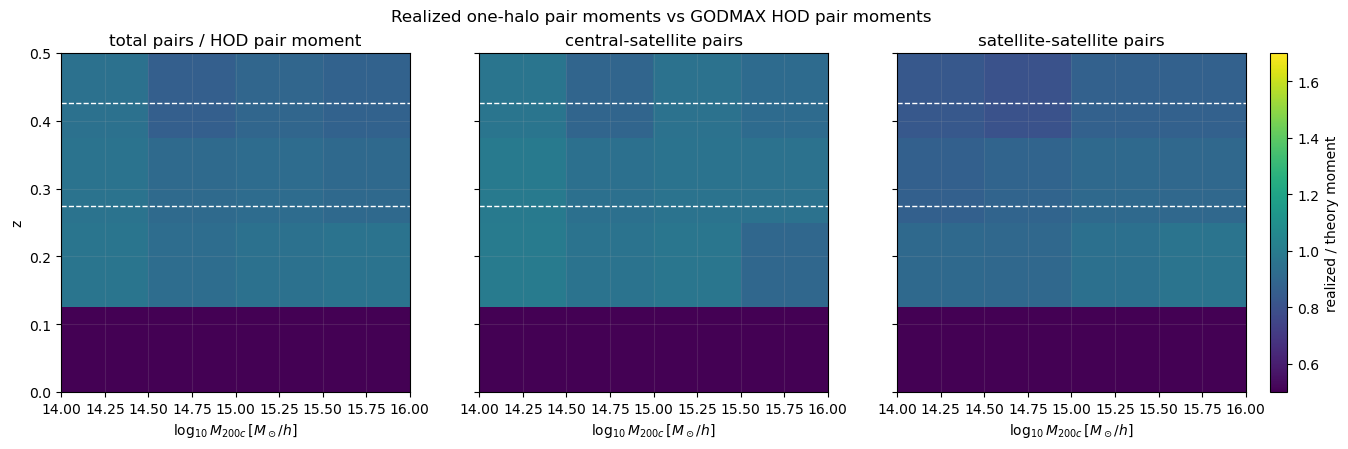

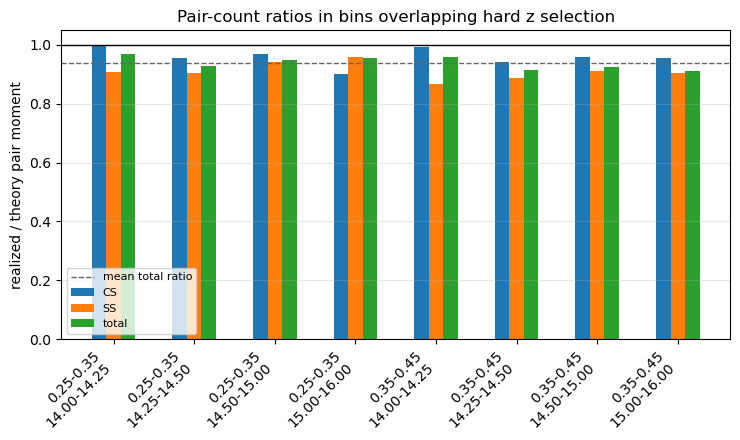

Interpretation: compare pair_over_pred_poisson to gg/theory ~ 1.3217040504843383


In [17]:
pair_rows = agh.hod_pair_count_comparison(
    halo_catalog,
    galaxies,
    model_ref,
    z_edges=z_edges_diag,
    logm_edges=logm_edges_diag,
)
pair_df = pd.DataFrame(pair_rows)
display(pair_df)

# Summaries restricted to the redshift range that enters the hard-cut gg comparison.
zmask_pair = (pair_df['z_hi'] > z_range[0]) & (pair_df['z_lo'] < z_range[1])
summary_cols = [
    'actual_pair_total',
    'pred_pair_total_poisson',
    'pred_pair_total_same_gal_included',
    'actual_cs_ordered',
    'pred_cs_ordered',
    'actual_ss_ordered',
    'pred_ss_poisson_ordered',
]
summary_pair = pair_df.loc[zmask_pair, summary_cols].sum()
pair_summary = pd.DataFrame([
    {
        'selection': 'overlaps hard z_range',
        'z_range': z_range,
        'actual_pair_total': summary_pair['actual_pair_total'],
        'pred_pair_total_poisson': summary_pair['pred_pair_total_poisson'],
        'pair_over_pred_poisson': summary_pair['actual_pair_total'] / summary_pair['pred_pair_total_poisson'],
        'pred_pair_total_same_gal_included': summary_pair['pred_pair_total_same_gal_included'],
        'pair_over_pred_same_gal_included': summary_pair['actual_pair_total'] / summary_pair['pred_pair_total_same_gal_included'],
        'cs_over_pred': summary_pair['actual_cs_ordered'] / summary_pair['pred_cs_ordered'],
        'ss_over_pred_poisson': summary_pair['actual_ss_ordered'] / summary_pair['pred_ss_poisson_ordered'],
    }
])
display(pair_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
plot_specs = [
    ('pair_over_pred_poisson', 'total pairs / HOD pair moment'),
    ('cs_over_pred', 'central-satellite pairs'),
    ('ss_over_pred_poisson', 'satellite-satellite pairs'),
]
for ax, (col, title) in zip(axes, plot_specs):
    pivot = pair_df.pivot_table(index='z_lo', columns='logM_lo', values=col)
    im = ax.imshow(
        pivot.values,
        origin='lower',
        aspect='auto',
        vmin=0.5,
        vmax=1.7,
        extent=[logm_edges_diag[0], logm_edges_diag[-1], z_edges_diag[0], z_edges_diag[-1]],
    )
    ax.axhline(z_range[0], color='w', lw=1.0, ls='--')
    ax.axhline(z_range[1], color='w', lw=1.0, ls='--')
    ax.set_xlabel(r'$\log_{10}M_{200c}\,[M_\odot/h]$')
    ax.set_title(title)
    ax.grid(alpha=0.15)
axes[0].set_ylabel('z')
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='realized / theory moment')
fig.suptitle('Realized one-halo pair moments vs GODMAX HOD pair moments')
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sub = pair_df[zmask_pair].copy()
width = 0.18
x = np.arange(len(sub))
labels = [f'{r.z_lo:.2f}-{r.z_hi:.2f}\n{r.logM_lo:.2f}-{r.logM_hi:.2f}' for r in sub.itertuples()]
ax.bar(x - width, sub['cs_over_pred'], width=width, label='CS')
ax.bar(x, sub['ss_over_pred_poisson'], width=width, label='SS')
ax.bar(x + width, sub['pair_over_pred_poisson'], width=width, label='total')
ax.axhline(1.0, color='k', lw=1.0)
ax.axhline(np.nanmean(sub['pair_over_pred_poisson']), color='0.4', lw=1.0, ls='--', label='mean total ratio')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('realized / theory pair moment')
ax.set_title('Pair-count ratios in bins overlapping hard z selection')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print('Interpretation: compare pair_over_pred_poisson to gg/theory ~', float(summary_df[(summary_df['comparison'] == 'hard-cut map / fit n(z) theory') & (summary_df['ell_range'] == 'small')]['ratio_mean'].iloc[0]) if 'summary_df' in globals() else 'rerun final summary cell')


## Deterministic HOD-weighted halo clustering test

This is a fast point-map diagnostic. It does not paste satellite radial profiles. Instead it puts the GODMAX HOD expectation weights on the Abacus parent halo positions and subtracts the weighted point self-term. The main comparison is the `Ncen + Nsat` weighted halo map against the projected 2-halo galaxy theory on large/intermediate scales. If this ratio is already high by the same amount as `gg`, the problem is likely a halo-clustering/projection/bias normalization mismatch rather than stochastic HOD pair counts.


halo-weight test theory key: tophat_hard_selection_nonsymbolic
halo-weight test nside/lmax: 1024 3000
weighted halo maps and spectra finished in 5.5s


,weight,label,n_halos_used,sum_weight,sum_weight_sq,mean_weight_per_pix,weighted_point_self_term
0,ncen,$\langle N_{cen}\rangle$,65042,60965.826582,57908.363198,0.004845,0.000196
1,nsat,$\langle N_{sat}\rangle$,65042,91514.983972,298916.953533,0.007273,0.000449
2,ntot,$\langle N_{cen}\rangle + \langle N_{sat}\rangle$,65042,152480.810553,535791.785128,0.012118,0.000290


projected 1h/2h components finished in 0.0s


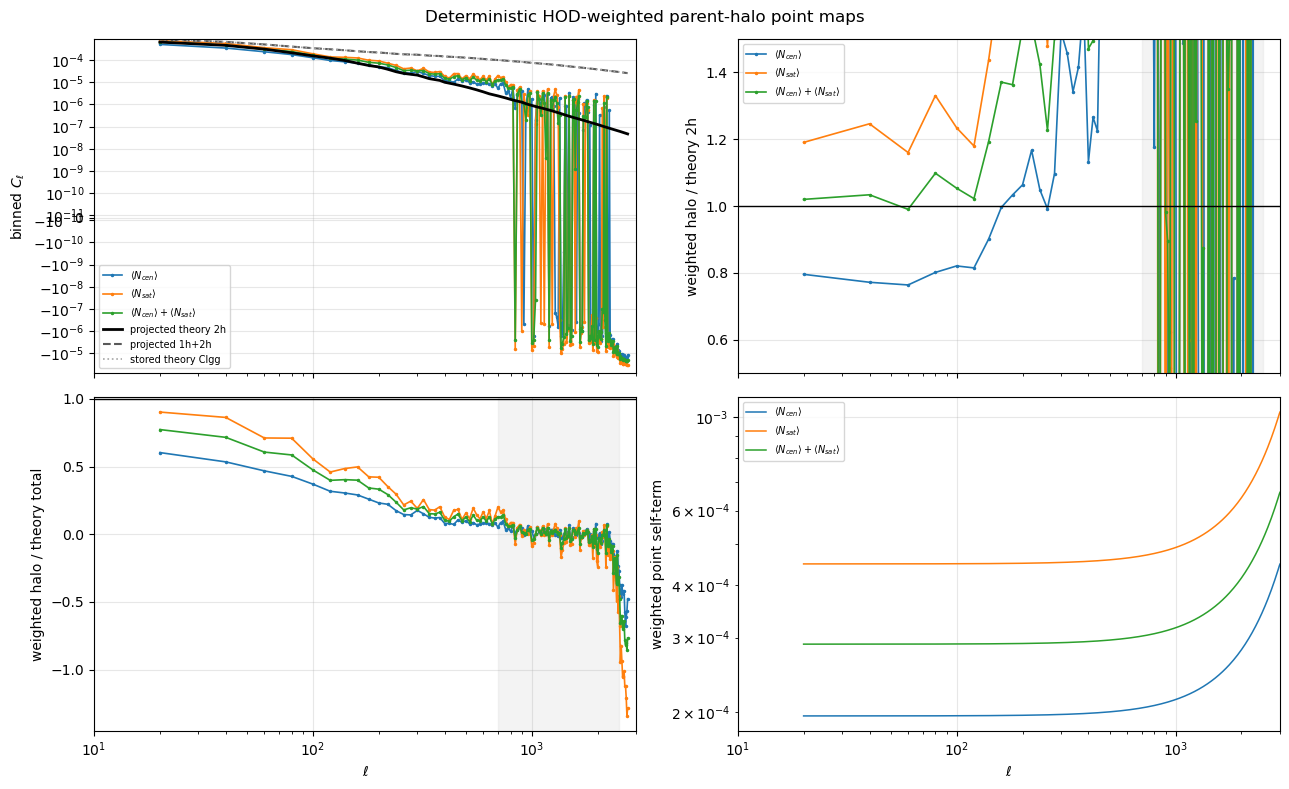

,weight,ell_range,mean_over_2h,sqrt_mean_over_2h,mean_over_total,sqrt_mean_over_total,n_ell
0,ncen,large/intermediate,1.018624,0.982945,0.250735,0.484616,221
1,ncen,small,-9.494302,2.047042,-0.013477,0.151428,1801
2,nsat,large/intermediate,1.624925,1.220561,0.400274,0.603764,221
3,nsat,small,-21.706009,2.817518,-0.047083,0.205939,1801
4,ntot,large/intermediate,1.340471,1.124156,0.330796,0.555097,221
5,ntot,small,-14.428334,2.305588,-0.027761,0.170419,1801


Interpretation: if ntot large/intermediate mean_over_2h is close to the gg/theory excess,
the mismatch is already present in the weighted parent-halo clustering/projection. If it is near 1,
then the remaining gg issue is more likely in satellite radial placement or map-level estimator details.


In [19]:
HALO_WEIGHT_TEST_NSIDE = min(NSIDE, 1024)
HALO_WEIGHT_TEST_LMAX = min(ELL_MAX, 3 * HALO_WEIGHT_TEST_NSIDE - 1)
HALO_WEIGHT_THEORY_KEY = 'tophat_hard_selection_nonsymbolic' if 'tophat_hard_selection_nonsymbolic' in theory_bundles else CURRENT_KEY
halo_weight_model = theory_bundles[HALO_WEIGHT_THEORY_KEY]['cmb']
print('halo-weight test theory key:', HALO_WEIGHT_THEORY_KEY)
print('halo-weight test nside/lmax:', HALO_WEIGHT_TEST_NSIDE, HALO_WEIGHT_TEST_LMAX)

t0 = time.perf_counter()
hod_weights = agh.hod_expectation_weights(halo_catalog, halo_weight_model)
weight_specs = [
    ('ncen', r'$\langle N_{cen}\rangle$'),
    ('nsat', r'$\langle N_{sat}\rangle$'),
    ('ntot', r'$\langle N_{cen}\rangle + \langle N_{sat}\rangle$'),
]

halo_weight_cls = {}
weight_rows = []
for key, label in weight_specs:
    cls = agh.measure_catalog_weighted_cls(
        halo_catalog,
        HALO_WEIGHT_TEST_NSIDE,
        hod_weights[key],
        z_range=z_range,
        lmax=HALO_WEIGHT_TEST_LMAX,
        pixwin_correction=True,
    )
    halo_weight_cls[key] = cls
    weight_rows.append({
        'weight': key,
        'label': label,
        'n_halos_used': cls['n_obj'],
        'sum_weight': cls['sumw'],
        'sum_weight_sq': cls['sumw2'],
        'mean_weight_per_pix': cls['mean_per_pix'],
        'weighted_point_self_term': cls['shot'],
    })
print(f'weighted halo maps and spectra finished in {time.perf_counter() - t0:.1f}s')
display(pd.DataFrame(weight_rows))

# The deterministic point map is meant to test the large-scale weighted-halo field.
# Compare it to the 2-halo piece. Small-scale ratios are shown as a warning region,
# because point satellites are not a physical replacement for the pasted radial profile.
t0 = time.perf_counter()
halo_weight_decomp = agh.response_decomposed_pgg_cls(halo_weight_model, COMPARE_BIN)
halo_weight_decomp_key = HALO_WEIGHT_THEORY_KEY
print(f'projected 1h/2h components finished in {time.perf_counter() - t0:.1f}s')

th_total = theory_curves[HALO_WEIGHT_THEORY_KEY]
ell_th = np.asarray(halo_weight_decomp['ell'])
th_2h = np.asarray(halo_weight_decomp['gg_2h'])
th_sum = np.asarray(halo_weight_decomp['gg_sum'])
th_stored = np.asarray(th_total['gg'])

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
ax_cl, ax_ratio_2h, ax_ratio_tot, ax_shot = axes.ravel()
colors = {'ncen': 'tab:blue', 'nsat': 'tab:orange', 'ntot': 'tab:green'}
for key, label in weight_specs:
    cls = halo_weight_cls[key]
    th_2h_on_ell = np.interp(cls['ell'], ell_th, th_2h, left=np.nan, right=np.nan)
    th_sum_on_ell = np.interp(cls['ell'], ell_th, th_sum, left=np.nan, right=np.nan)
    b2 = agh.bin_pair(cls['ell'], cls['cl_without_shot'], th_2h_on_ell, ell_min=ELL_MIN, ell_max=HALO_WEIGHT_TEST_LMAX, delta_ell=DELTA_ELL)
    bt = agh.bin_pair(cls['ell'], cls['cl_without_shot'], th_sum_on_ell, ell_min=ELL_MIN, ell_max=HALO_WEIGHT_TEST_LMAX, delta_ell=DELTA_ELL)
    ax_cl.plot(b2['ell'], b2['value_a'], marker='.', ms=3, lw=1.2, color=colors[key], label=label)
    ax_ratio_2h.plot(b2['ell'], b2['ratio'], marker='.', ms=3, lw=1.2, color=colors[key], label=label)
    ax_ratio_tot.plot(bt['ell'], bt['ratio'], marker='.', ms=3, lw=1.2, color=colors[key], label=label)
    shot_b = psh.bin_spectrum(cls['ell'], cls['shot_deconvolved'], ell_min=ELL_MIN, ell_max=HALO_WEIGHT_TEST_LMAX, delta_ell=DELTA_ELL)
    ax_shot.plot(shot_b['ell'], shot_b['value'], lw=1.1, color=colors[key], label=label)

theory_2h_b = psh.bin_spectrum(ell_th, th_2h, ell_min=ELL_MIN, ell_max=HALO_WEIGHT_TEST_LMAX, delta_ell=DELTA_ELL)
theory_sum_b = psh.bin_spectrum(ell_th, th_sum, ell_min=ELL_MIN, ell_max=HALO_WEIGHT_TEST_LMAX, delta_ell=DELTA_ELL)
stored_b = psh.bin_spectrum(th_total['ell'], th_stored, ell_min=ELL_MIN, ell_max=HALO_WEIGHT_TEST_LMAX, delta_ell=DELTA_ELL)
ax_cl.plot(theory_2h_b['ell'], theory_2h_b['value'], color='k', lw=2.0, label='projected theory 2h')
ax_cl.plot(theory_sum_b['ell'], theory_sum_b['value'], color='0.35', lw=1.5, ls='--', label='projected 1h+2h')
ax_cl.plot(stored_b['ell'], stored_b['value'], color='0.65', lw=1.2, ls=':', label='stored theory Clgg')

for ax in axes.ravel():
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim(ELL_MIN, HALO_WEIGHT_TEST_LMAX)
ax_cl.set_yscale('symlog', linthresh=1e-10)
ax_shot.set_yscale('log')
for ax in (ax_ratio_2h, ax_ratio_tot):
    ax.axhline(1.0, color='k', lw=1.0)
    ax.axvspan(SMALL_SCALE_ELL_RANGE[0], min(SMALL_SCALE_ELL_RANGE[1], HALO_WEIGHT_TEST_LMAX), color='0.85', alpha=0.3)
ax_cl.set_ylabel(r'binned $C_\ell$')
ax_ratio_2h.set_ylabel('weighted halo / theory 2h')
ax_ratio_2h.set_ylim(0.5, 1.5)
ax_ratio_tot.set_ylabel('weighted halo / theory total')
ax_shot.set_ylabel('weighted point self-term')
for ax in axes[-1]:
    ax.set_xlabel(r'$\ell$')
ax_cl.legend(fontsize=7)
ax_ratio_2h.legend(fontsize=7)
ax_shot.legend(fontsize=7)
fig.suptitle('Deterministic HOD-weighted parent-halo point maps')
fig.tight_layout()
plt.show()

range_rows = []
for key, label in weight_specs:
    cls = halo_weight_cls[key]
    th_2h_on_ell = np.interp(cls['ell'], ell_th, th_2h, left=np.nan, right=np.nan)
    th_sum_on_ell = np.interp(cls['ell'], ell_th, th_sum, left=np.nan, right=np.nan)
    for lo, hi, tag in [(80, 300, 'large/intermediate'), SMALL_SCALE_ELL_RANGE + ('small',)]:
        hi_eff = min(int(hi), HALO_WEIGHT_TEST_LMAX)
        mask = (cls['ell'] >= int(lo)) & (cls['ell'] <= hi_eff) & np.isfinite(cls['cl_without_shot'])
        ratio_2h = cls['cl_without_shot'][mask] / th_2h_on_ell[mask]
        ratio_sum = cls['cl_without_shot'][mask] / th_sum_on_ell[mask]
        range_rows.append({
            'weight': key,
            'ell_range': tag,
            'mean_over_2h': float(np.nanmean(ratio_2h)),
            'sqrt_mean_over_2h': float(np.nanmean(np.sqrt(np.clip(ratio_2h, 0, np.inf)))),
            'mean_over_total': float(np.nanmean(ratio_sum)),
            'sqrt_mean_over_total': float(np.nanmean(np.sqrt(np.clip(ratio_sum, 0, np.inf)))),
            'n_ell': int(np.count_nonzero(mask)),
        })
halo_weight_summary_df = pd.DataFrame(range_rows)
display(halo_weight_summary_df)

print('Interpretation: if ntot large/intermediate mean_over_2h is close to the gg/theory excess,')
print('the mismatch is already present in the weighted parent-halo clustering/projection. If it is near 1,')
print('then the remaining gg issue is more likely in satellite radial placement or map-level estimator details.')


## Explicit halo mass function: Abacus catalog vs GODMAX theory

This is the clean HMF comparison.  The catalog points are direct counts in `(z, log10 M200c_hMsun)` bins divided by full-sky comoving shell volume and `dlnM`.  The theory curves are `GODMAX hmf_Mz_mat = dn/dlnM` on the same `M200c_hMsun` mass definition.


Catalog mass column: M200c_hMsun
Catalog mass unit: Msun/h
Catalog mass provenance: Interpolated_N * ParticleMassHMsun from halo_lightcone
Theory mass grid: M200c_hMsun
Theory HMF model: T10
HMF quantity: dn/dlnM, units (h/Mpc)^3
Volume convention: flat LCDM comoving volume in (Mpc/h)^3 with fsky= 1.0 Omega_M= 0.3175


,z_lo,z_hi,z_mid,logM_lo,logM_hi,logM_mid,count,volume_hMpc3,dndlnM,poisson_err,mass_definition,hmf_units
0,0.15,0.25,0.2,14.0,14.1,14.05,6959,1.117431e+09,0.000027,3.242178e-07,M200c_hMsun,(h/Mpc)^3 per dlnM
1,0.15,0.25,0.2,14.1,14.2,14.15,5031,1.117431e+09,0.000020,2.756707e-07,M200c_hMsun,(h/Mpc)^3 per dlnM
2,0.15,0.25,0.2,14.2,14.3,14.25,3485,1.117431e+09,0.000014,2.294377e-07,M200c_hMsun,(h/Mpc)^3 per dlnM
3,0.15,0.25,0.2,14.3,14.4,14.35,2365,1.117431e+09,0.000009,1.890075e-07,M200c_hMsun,(h/Mpc)^3 per dlnM
4,0.15,0.25,0.2,14.4,14.5,14.45,1375,1.117431e+09,0.000005,1.441169e-07,M200c_hMsun,(h/Mpc)^3 per dlnM


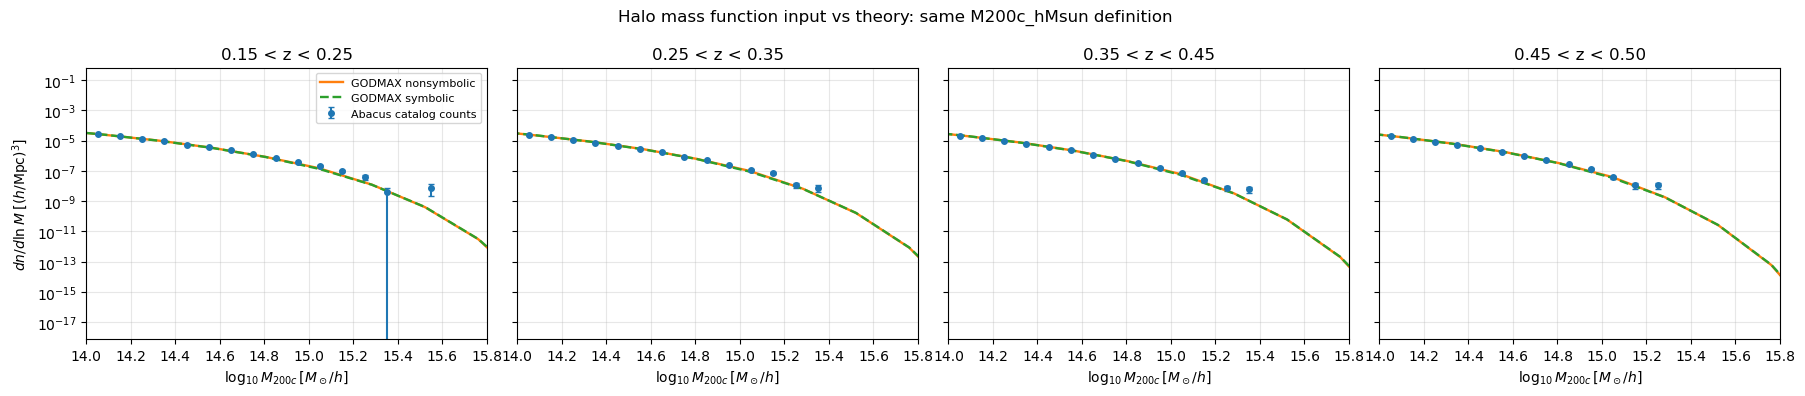

,z_lo,z_hi,theory,median_catalog_over_theory,mean_catalog_over_theory,n_mass_bins
0,0.15,0.25,fit_nz_current_nonsymbolic,0.974528,2.367276,15
1,0.15,0.25,fit_nz_current_symbolic,0.971702,2.364650,15
2,0.25,0.35,fit_nz_current_nonsymbolic,0.921083,0.964907,14
3,0.25,0.35,fit_nz_current_symbolic,0.917190,0.996140,14
4,0.35,0.45,fit_nz_current_nonsymbolic,0.857851,0.964506,14
5,0.35,0.45,fit_nz_current_symbolic,0.866048,0.995287,14
6,0.45,0.50,fit_nz_current_nonsymbolic,0.862319,0.890800,13
7,0.45,0.50,fit_nz_current_symbolic,0.876778,0.927155,13


In [7]:
HMF_Z_SLICES = [(0.15, 0.25), (0.25, 0.35), (0.35, 0.45), (0.45, 0.50)]
HMF_LOGM_EDGES = np.arange(14.0, 15.81, 0.10)
HMF_FSKY = 1.0
omega_m_for_volume = float(halo_attrs.get('Omega_M', model_ref.base.cosmo_params['Om0']))

print('Catalog mass column:', halo_attrs.get('mass_column', 'M200c_hMsun'))
print('Catalog mass unit:', halo_attrs.get('mass_unit', 'Msun/h'))
print('Catalog mass provenance:', halo_attrs.get('mass_provenance', ''))
print('Theory mass grid:', f'M{int(model_ref.base.mdef_Delta)}c_hMsun')
print('Theory HMF model:', model_ref.base.hmf_model)
print('HMF quantity: dn/dlnM, units (h/Mpc)^3')
print('Volume convention: flat LCDM comoving volume in (Mpc/h)^3 with fsky=', HMF_FSKY, 'Omega_M=', omega_m_for_volume)

cat_hmf_df = pd.DataFrame(agh.catalog_hmf_points(
    halo_catalog,
    z_slices=HMF_Z_SLICES,
    logm_edges=HMF_LOGM_EDGES,
    omega_m=omega_m_for_volume,
    fsky=HMF_FSKY,
))
display(cat_hmf_df.head())

fig, axes = plt.subplots(1, len(HMF_Z_SLICES), figsize=(4.5 * len(HMF_Z_SLICES), 4.0), sharey=True)
if len(HMF_Z_SLICES) == 1:
    axes = [axes]
for ax, zslice in zip(axes, HMF_Z_SLICES):
    zlo, zhi = zslice
    zmid = 0.5 * (zlo + zhi)
    sub = cat_hmf_df[(cat_hmf_df['z_lo'] == zlo) & (cat_hmf_df['z_hi'] == zhi) & (cat_hmf_df['count'] > 0)]
    ax.errorbar(
        sub['logM_mid'],
        sub['dndlnM'],
        yerr=sub['poisson_err'],
        fmt='o',
        ms=4,
        capsize=2,
        label='Abacus catalog counts',
    )
    for theory_key, style in [('fit_nz_current_nonsymbolic', '-'), ('fit_nz_current_symbolic', '--')]:
        if theory_key not in theory_bundles:
            continue
        curve = agh.theory_hmf_curve(theory_bundles[theory_key]['cmb'], zmid)
        ax.plot(
            curve['log10M200c_hMsun'],
            curve['dndlnM'],
            style,
            lw=1.7,
            label=f'GODMAX {theory_key.replace("fit_nz_current_", "")}',
        )
    ax.set_yscale('log')
    ax.set_xlim(HMF_LOGM_EDGES[0], HMF_LOGM_EDGES[-1])
    ax.set_xlabel(r'$\log_{10} M_{200c}\,[M_\odot/h]$')
    ax.set_title(f'{zlo:.2f} < z < {zhi:.2f}')
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r'$dn/d\ln M\;[(h/{\rm Mpc})^3]$')
axes[0].legend(fontsize=8)
fig.suptitle('Halo mass function input vs theory: same M200c_hMsun definition')
fig.tight_layout()
plt.show()

ratio_rows = []
for zslice in HMF_Z_SLICES:
    zlo, zhi = zslice
    zmid = 0.5 * (zlo + zhi)
    sub = cat_hmf_df[(cat_hmf_df['z_lo'] == zlo) & (cat_hmf_df['z_hi'] == zhi) & (cat_hmf_df['count'] > 0)].copy()
    for theory_key in ['fit_nz_current_nonsymbolic', 'fit_nz_current_symbolic']:
        if theory_key not in theory_bundles:
            continue
        curve = agh.theory_hmf_curve(theory_bundles[theory_key]['cmb'], zmid)
        theory_at_bins = np.interp(sub['logM_mid'], curve['log10M200c_hMsun'], curve['dndlnM'], left=np.nan, right=np.nan)
        valid = np.isfinite(theory_at_bins) & (theory_at_bins > 0)
        ratio_rows.append({
            'z_lo': zlo,
            'z_hi': zhi,
            'theory': theory_key,
            'median_catalog_over_theory': float(np.nanmedian(sub['dndlnM'].values[valid] / theory_at_bins[valid])) if np.any(valid) else np.nan,
            'mean_catalog_over_theory': float(np.nanmean(sub['dndlnM'].values[valid] / theory_at_bins[valid])) if np.any(valid) else np.nan,
            'n_mass_bins': int(np.count_nonzero(valid)),
        })
display(pd.DataFrame(ratio_rows))


## Satellite projected profile around generated halos

This stacks actual generated satellites around nearby selected halo centers and compares to the projected profile implied by the same CDF construction used in `get_sim_maps.py`.  Large discrepancies here would point to satellite placement/profile normalization rather than angular projection.


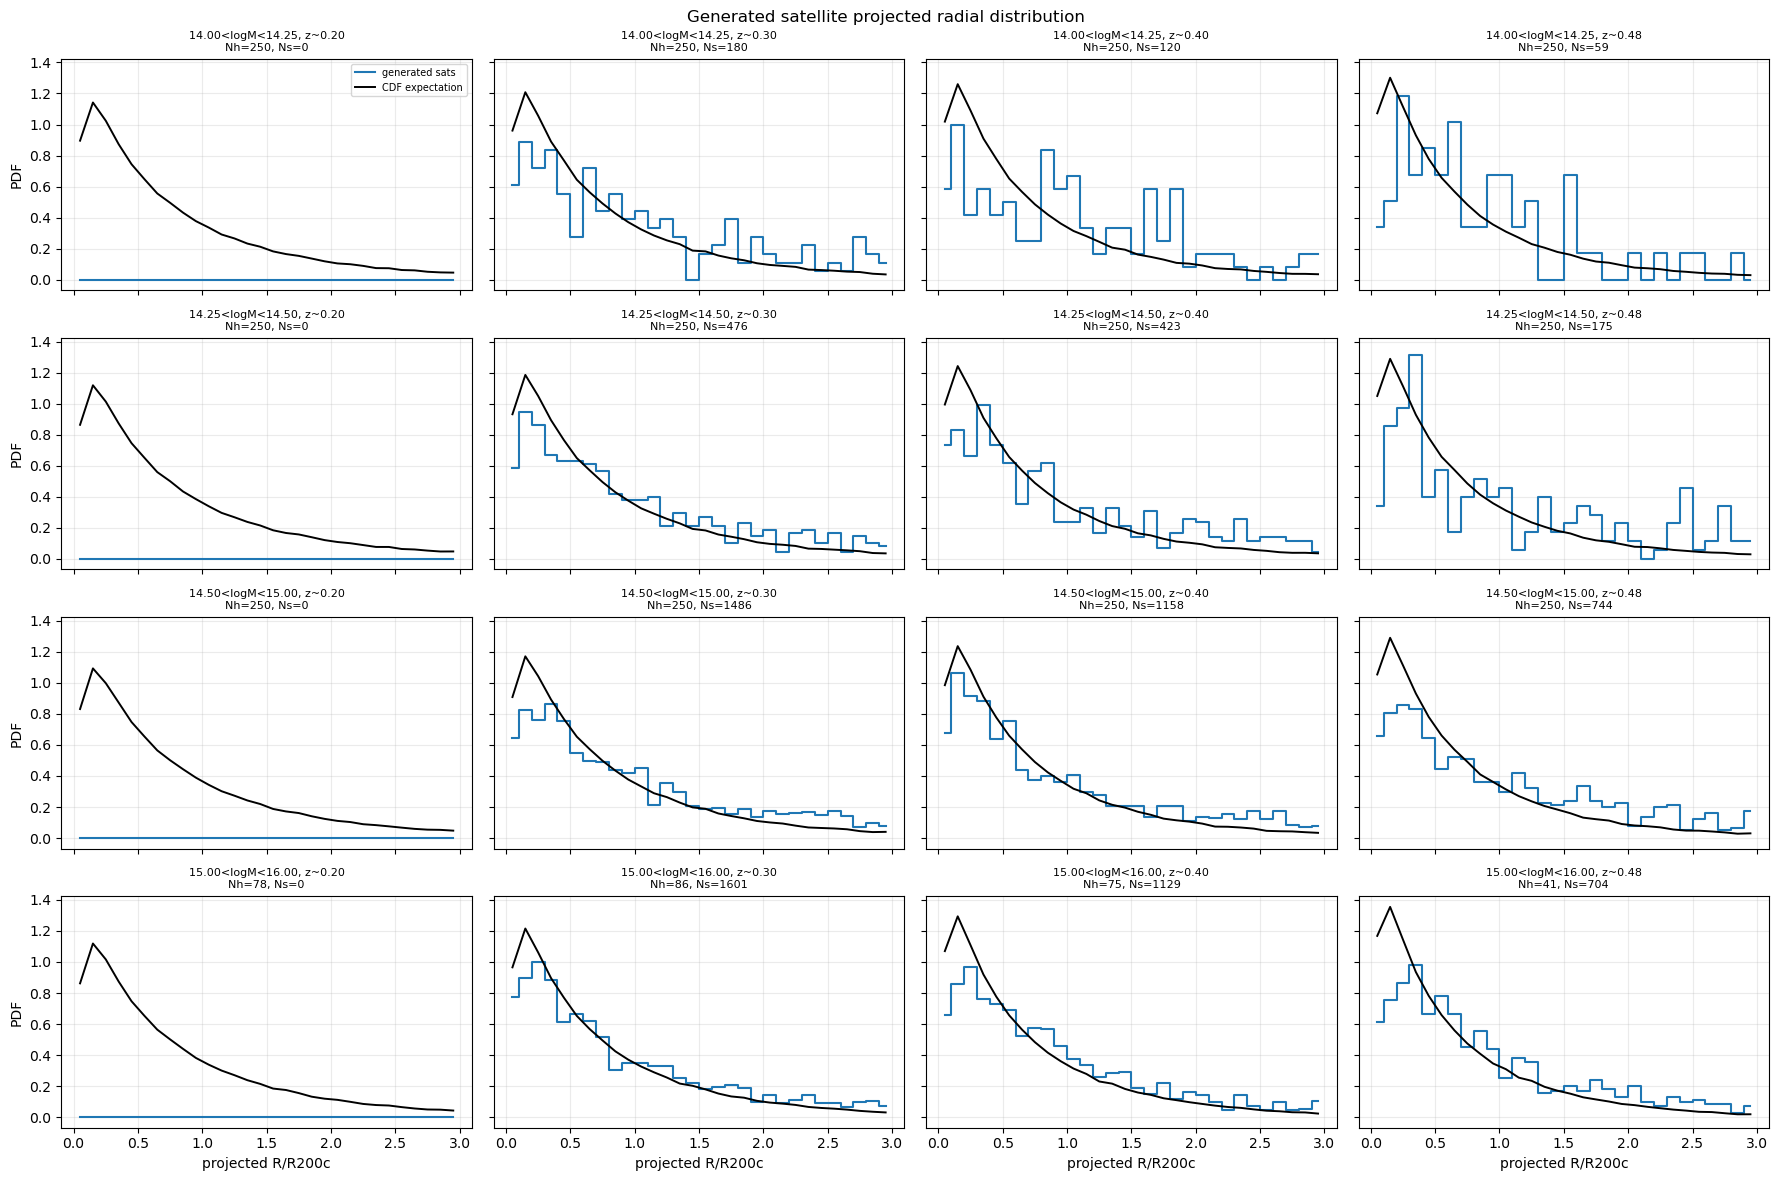

,logM_lo,logM_hi,z_center,n_halos,n_sat_matched
0,14.00,14.25,0.20,250,0
1,14.00,14.25,0.30,250,180
2,14.00,14.25,0.40,250,120
3,14.00,14.25,0.48,250,59
4,14.25,14.50,0.20,250,0
5,14.25,14.50,0.30,250,476
6,14.25,14.50,0.40,250,423
7,14.25,14.50,0.48,250,175
8,14.50,15.00,0.20,250,0
9,14.50,15.00,0.30,250,1486


In [8]:
profile_rows = []
fig, axes = plt.subplots(len(MASS_BINS), len(Z_CENTERS), figsize=(18, 12), sharex=True, sharey=True)
for im, mbin in enumerate(MASS_BINS):
    for iz, zc in enumerate(Z_CENTERS):
        ax = axes[im, iz]
        zbin = (max(0.0, zc - Z_HALF_WIDTH), min(0.5, zc + Z_HALF_WIDTH))
        hidx = agh.select_halos(halo_catalog, logm_range=mbin, z_range=zbin, max_halos=MAX_STACK_HALOS, seed=1000 + 10 * im + iz)
        if len(hidx) == 0:
            ax.text(0.5, 0.5, 'no halos', transform=ax.transAxes, ha='center', va='center')
            ax.set_axis_off()
            continue
        stack = agh.stack_satellites_projected_r200(galaxies, halo_catalog, hidx, PROFILE_RADIAL_EDGES_R200)
        logm_mid = 0.5 * (mbin[0] + min(mbin[1], 15.6))
        expected = agh.expected_projected_satellite_hist(model_ref, logm=logm_mid, z=zc, radial_edges_r200=PROFILE_RADIAL_EDGES_R200)
        dr = np.diff(PROFILE_RADIAL_EDGES_R200)
        obs_pdf = stack['counts'] / np.maximum(np.sum(stack['counts']) * dr, 1.0)
        ax.step(stack['r_mid'], obs_pdf, where='mid', label='generated sats')
        ax.plot(expected['r_mid'], expected['pdf'], color='k', lw=1.4, label='CDF expectation')
        ax.set_title(f'{mbin[0]:.2f}<logM<{mbin[1]:.2f}, z~{zc:.2f}\nNh={len(hidx)}, Ns={stack.get("n_sat_matched", 0)}', fontsize=8)
        ax.grid(alpha=0.25)
        profile_rows.append({'logM_lo': mbin[0], 'logM_hi': mbin[1], 'z_center': zc, 'n_halos': len(hidx), 'n_sat_matched': stack.get('n_sat_matched', 0)})
        if im == len(MASS_BINS) - 1:
            ax.set_xlabel('projected R/R200c')
        if iz == 0:
            ax.set_ylabel('PDF')
axes[0, 0].legend(fontsize=7)
fig.suptitle('Generated satellite projected radial distribution')
fig.tight_layout()
plt.show()
display(pd.DataFrame(profile_rows))


## Real pasted-map radial stacks around halos

This stacks the already pasted maps around selected halos.  It is not a full theory comparison by itself, but it checks whether field morphology around halos is sensible and whether one field has an obvious normalization/pathology relative to the others.


map-stack halos: 250 logM range: (14.25, 14.5) z range: (0.25, 0.35)


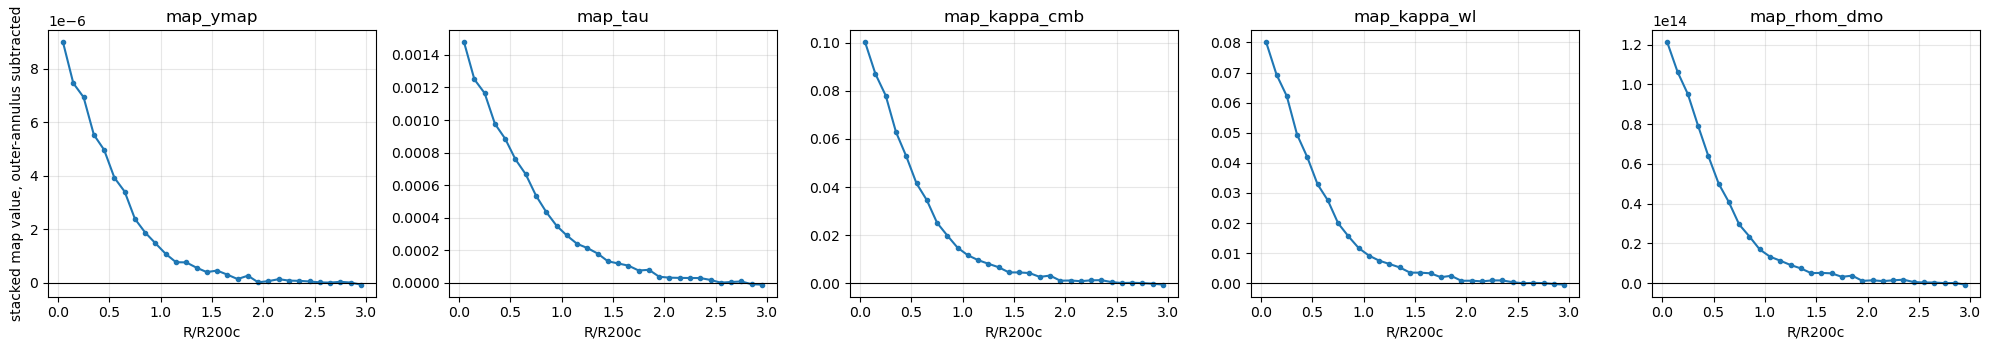

In [9]:
STACK_LOGM_RANGE = (14.25, 14.5)
STACK_Z_RANGE = (0.25, 0.35)
stack_idx = agh.select_halos(halo_catalog, logm_range=STACK_LOGM_RANGE, z_range=STACK_Z_RANGE, max_halos=MAX_STACK_HALOS, seed=4321)
print('map-stack halos:', len(stack_idx), 'logM range:', STACK_LOGM_RANGE, 'z range:', STACK_Z_RANGE)

stack_fields = ['map_ymap', 'map_tau', 'map_kappa_cmb', 'map_kappa_wl', 'map_rhom_dmo']
fig, axes = plt.subplots(1, len(stack_fields), figsize=(4.0 * len(stack_fields), 3.6), sharex=True)
for ax, field in zip(axes, stack_fields):
    prof = agh.stack_map_around_halos(maps_pasted[field], halo_catalog, NSIDE, stack_idx, PROFILE_RADIAL_EDGES_R200)
    y = prof['mean'].copy()
    if np.any(np.isfinite(y)):
        y = y - np.nanmedian(y[-5:])
    ax.plot(prof['r_mid'], y, marker='o', ms=3)
    ax.axhline(0.0, color='k', lw=0.8)
    ax.set_title(field)
    ax.set_xlabel('R/R200c')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('stacked map value, outer-annulus subtracted')
fig.tight_layout()
plt.show()


## Optional isolated-halo paint checks

Set `RUN_SYNTHETIC_PAINT=True` in the settings cell to paint one synthetic halo at fixed `(M,z)`.  This directly tests the map painter/profile interpolation path for `y`, `tau`, `kappa`, and mass templates without catalog/HMF/n(z) complications.


In [10]:
if RUN_SYNTHETIC_PAINT:
    SYNTHETIC_NSIDE = min(NSIDE, 1024)
    synth_mass = 10**14.5
    synth_z = 0.3
    cmb_bundle = theory_bundles[CURRENT_KEY]['cmb']
    wl_bundle = theory_bundles[CURRENT_KEY]['wl'] if theory_bundles[CURRENT_KEY]['wl'] is not None else None
    synth_cmb = agh.paint_single_halo_maps(cfg, cmb_bundle, mass_hMsun=synth_mass, z=synth_z, nside=SYNTHETIC_NSIDE)
    synth_wl = agh.paint_single_halo_maps(cfg, wl_bundle, mass_hMsun=synth_mass, z=synth_z, nside=SYNTHETIC_NSIDE) if wl_bundle is not None else None
    synth_catalog = synth_cmb['catalog']
    synth_idx = np.asarray([0], dtype=np.int64)
    fields = [('y', synth_cmb['maps']['map_ymap']), ('tau', synth_cmb['maps']['map_tau']), ('kappa_cmb', synth_cmb['maps']['map_kappa'])]
    if synth_wl is not None:
        fields.append(('kappa_wl', synth_wl['maps']['map_kappa']))
    fields.extend([('rhom', synth_cmb['maps']['map_rhom']), ('rhom_dmo', synth_cmb['maps']['map_rhom_dmo'])])
    fig, axes = plt.subplots(1, len(fields), figsize=(4.0 * len(fields), 3.5), sharex=True)
    for ax, (name, fmap) in zip(axes, fields):
        prof = agh.stack_map_around_halos(fmap, synth_catalog, SYNTHETIC_NSIDE, synth_idx, PROFILE_RADIAL_EDGES_R200)
        ax.plot(prof['r_mid'], prof['mean'], marker='o', ms=3)
        ax.set_title(name)
        ax.set_xlabel('R/R200c')
        ax.grid(alpha=0.3)
    axes[0].set_ylabel('single-halo painted profile')
    fig.tight_layout()
    plt.show()
else:
    print('RUN_SYNTHETIC_PAINT=False; skipping isolated-halo paint checks.')


RUN_SYNTHETIC_PAINT=False; skipping isolated-halo paint checks.


## Final Cl_gg checks for matched map/theory windows

The main comparison is `gg_without_shot` against clustering-only theory.  The same plot also shows `sqrt(gg/theory)`, which is useful because a pure galaxy-bias amplitude mismatch enters `gg` quadratically.


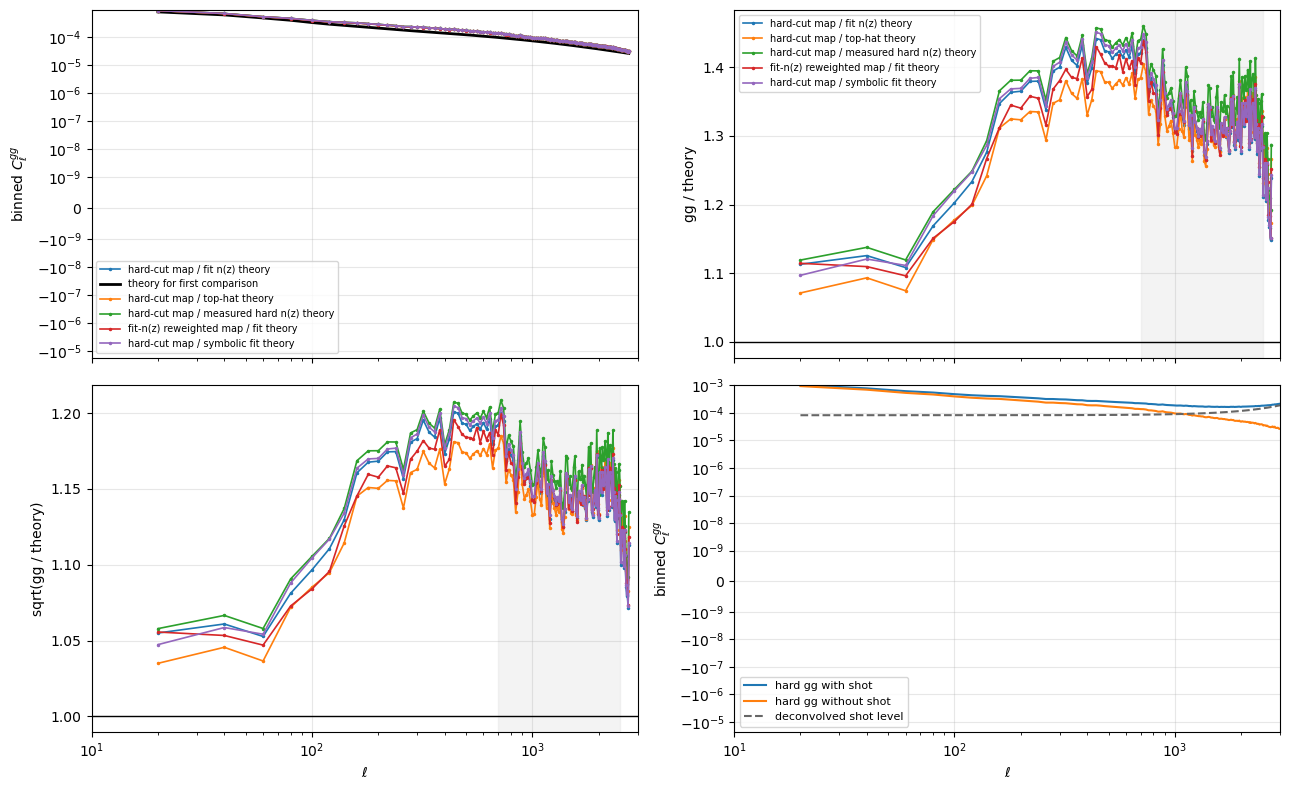

,comparison,small_scale_ratio_mean,small_scale_sqrt_ratio_mean,n_ell
0,hard-cut map / fit n(z) theory,1.321704,1.148850,1801
1,hard-cut map / top-hat theory,1.318346,1.147409,1801
2,hard-cut map / measured hard n(z) theory,1.355348,1.163395,1801
3,fit-n(z) reweighted map / fit theory,1.323804,1.149804,1801
4,hard-cut map / symbolic fit theory,1.326224,1.150808,1801


hard-cut Ngal: 152180 shot: 8.257570386620562e-05


In [11]:
cls_variants = {
    'hard_cut': agh.measure_weighted_cls(maps_pasted, galaxies, NSIDE, z_range=z_range, pixwin_correction=True),
    'fit_nz_reweighted': agh.measure_weighted_cls(maps_pasted, galaxies, NSIDE, weights=fit_reweight, pixwin_correction=True),
    'all_generated': agh.measure_weighted_cls(maps_pasted, galaxies, NSIDE, pixwin_correction=True),
}

comparison_specs = [
    ('hard_cut', 'fit_nz_current_nonsymbolic', 'hard-cut map / fit n(z) theory'),
    ('hard_cut', 'tophat_hard_selection_nonsymbolic', 'hard-cut map / top-hat theory'),
    ('hard_cut', 'measured_hard_selection_nonsymbolic', 'hard-cut map / measured hard n(z) theory'),
    ('fit_nz_reweighted', 'fit_nz_current_nonsymbolic', 'fit-n(z) reweighted map / fit theory'),
]
if 'fit_nz_current_symbolic' in theory_curves:
    comparison_specs.append(('hard_cut', 'fit_nz_current_symbolic', 'hard-cut map / symbolic fit theory'))

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
ax_cl, ax_ratio, ax_sqrt, ax_shot = axes.ravel()
for map_name, theory_name, label in comparison_specs:
    cls = cls_variants[map_name]
    th = theory_curves[theory_name]
    th_on_ell = np.interp(cls['ell'], th['ell'], th['gg'], left=np.nan, right=np.nan)
    b = agh.bin_pair(cls['ell'], cls['gg_without_shot'], th_on_ell, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    ax_cl.plot(b['ell'], b['value_a'], marker='.', ms=3, lw=1.2, label=label)
    ax_ratio.plot(b['ell'], b['ratio'], marker='.', ms=3, lw=1.2, label=label)
    ax_sqrt.plot(b['ell'], np.sqrt(np.clip(b['ratio'], 0, np.inf)), marker='.', ms=3, lw=1.2, label=label)
    if label == comparison_specs[0][2]:
        ax_cl.plot(b['ell'], b['value_b'], color='k', lw=2.0, label='theory for first comparison')

hard = cls_variants['hard_cut']
with_shot = psh.bin_spectrum(hard['ell'], hard['gg_with_shot'], ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
without_shot = psh.bin_spectrum(hard['ell'], hard['gg_without_shot'], ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
shot_for_plot = np.asarray(hard.get('shot_gg_deconvolved', np.full_like(hard['ell'], hard['shot_gg'], dtype=np.float64)))
shot = psh.bin_spectrum(hard['ell'], shot_for_plot, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
ax_shot.plot(with_shot['ell'], with_shot['value'], label='hard gg with shot')
ax_shot.plot(without_shot['ell'], without_shot['value'], label='hard gg without shot')
ax_shot.plot(shot['ell'], shot['value'], ls='--', color='0.4', label='deconvolved shot level')

for ax in axes.ravel():
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim(ELL_MIN, ELL_MAX)
ax_cl.set_yscale('symlog', linthresh=1e-9)
ax_shot.set_yscale('symlog', linthresh=1e-9)
ax_ratio.axhline(1.0, color='k', lw=1.0)
ax_sqrt.axhline(1.0, color='k', lw=1.0)
ax_ratio.axvspan(SMALL_SCALE_ELL_RANGE[0], SMALL_SCALE_ELL_RANGE[1], color='0.85', alpha=0.3)
ax_sqrt.axvspan(SMALL_SCALE_ELL_RANGE[0], SMALL_SCALE_ELL_RANGE[1], color='0.85', alpha=0.3)
ax_cl.set_ylabel(r'binned $C_\ell^{gg}$')
ax_ratio.set_ylabel('gg / theory')
ax_sqrt.set_ylabel('sqrt(gg / theory)')
ax_shot.set_ylabel(r'binned $C_\ell^{gg}$')
for ax in axes[-1]:
    ax.set_xlabel(r'$\ell$')
ax_cl.legend(fontsize=7)
ax_ratio.legend(fontsize=7)
ax_shot.legend(fontsize=8)
fig.tight_layout()
plt.show()

rows = []
for map_name, theory_name, label in comparison_specs:
    cls = cls_variants[map_name]
    th = theory_curves[theory_name]
    th_on_ell = np.interp(cls['ell'], th['ell'], th['gg'], left=np.nan, right=np.nan)
    ratio = cls['gg_without_shot'] / th_on_ell
    mask = (cls['ell'] >= SMALL_SCALE_ELL_RANGE[0]) & (cls['ell'] <= SMALL_SCALE_ELL_RANGE[1]) & np.isfinite(ratio)
    rows.append({'comparison': label, 'small_scale_ratio_mean': float(np.nanmean(ratio[mask])), 'small_scale_sqrt_ratio_mean': float(np.nanmean(np.sqrt(np.clip(ratio[mask], 0, np.inf)))), 'n_ell': int(np.count_nonzero(mask))})
display(pd.DataFrame(rows))
print('hard-cut Ngal:', hard['n_gal'], 'shot:', hard['shot_gg'])


## Cross-correlation ratios using the same galaxy maps

If `sqrt(gg/theory)` tracks the `gX/theory` ratios, the issue is mostly an effective galaxy-bias/window mismatch.  If `gg` alone is off while `gX` stays near unity, focus on the galaxy one-halo/profile/shot-noise terms.


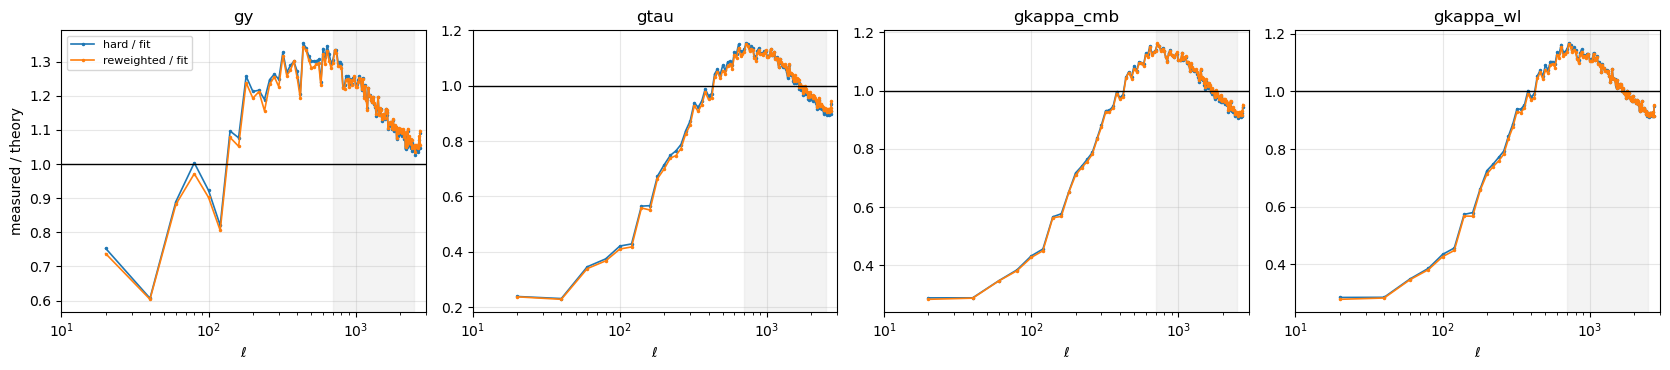

In [12]:
fields = ['gy', 'gtau', 'gkappa_cmb', 'gkappa_wl']
fig, axes = plt.subplots(1, len(fields), figsize=(4.2 * len(fields), 3.8), sharex=True)
for ax, field in zip(axes, fields):
    for map_name, theory_name, label in [('hard_cut', 'fit_nz_current_nonsymbolic', 'hard / fit'), ('fit_nz_reweighted', 'fit_nz_current_nonsymbolic', 'reweighted / fit')]:
        cls = cls_variants[map_name]
        th = theory_curves[theory_name]
        if field not in cls or field not in th:
            continue
        th_on_ell = np.interp(cls['ell'], th['ell'], th[field], left=np.nan, right=np.nan)
        b = agh.bin_pair(cls['ell'], cls[field], th_on_ell, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
        ax.plot(b['ell'], b['ratio'], marker='.', ms=3, lw=1.2, label=label)
    ax.axhline(1.0, color='k', lw=1.0)
    ax.axvspan(SMALL_SCALE_ELL_RANGE[0], SMALL_SCALE_ELL_RANGE[1], color='0.85', alpha=0.3)
    ax.set_xscale('log')
    ax.set_xlim(ELL_MIN, ELL_MAX)
    ax.set_title(field)
    ax.set_xlabel(r'$\ell$')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('measured / theory')
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Compare to original fitted Abacus Cl_gg product

This checks whether the current GODMAX theory setup still matches the original Clgg data product used for the HOD fit.  If symbolic/non-symbolic theory differs here, the pasted-map discrepancy may be partly a theory-configuration mismatch.


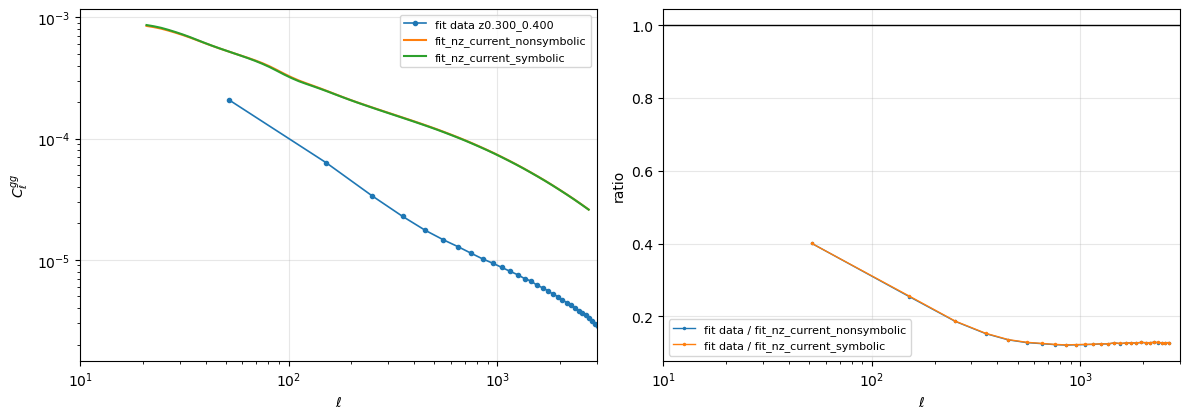

In [13]:
fit_ref = agh.load_fit_clgg_reference(cfg, COMPARE_BIN)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharex=True)
axes[0].plot(fit_ref['ell'], fit_ref['cl'], marker='o', ms=3, lw=1.2, label=f'fit data {fit_ref["key"]}')
for key in ['fit_nz_current_nonsymbolic', 'fit_nz_current_symbolic']:
    if key not in theory_curves:
        continue
    th = theory_curves[key]
    axes[0].plot(th['ell'], th['gg'], lw=1.5, label=key)
    th_on_ref = np.interp(fit_ref['ell'], th['ell'], th['gg'], left=np.nan, right=np.nan)
    axes[1].plot(fit_ref['ell'], fit_ref['cl'] / th_on_ref, marker='.', ms=3, lw=1.0, label=f'fit data / {key}')
axes[1].axhline(1.0, color='k', lw=1.0)
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlim(ELL_MIN, ELL_MAX)
    ax.grid(alpha=0.3)
    ax.set_xlabel(r'$\ell$')
axes[0].set_yscale('log')
axes[0].set_ylabel(r'$C_\ell^{gg}$')
axes[1].set_ylabel('ratio')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Theory 1-halo / 2-halo decomposition

This projects the `Pgg_1h` and `Pgg_2h` components with the same lens kernel.  Small-scale disagreements that line up with the 1-halo-dominated range point toward satellite occupation/profile assumptions.


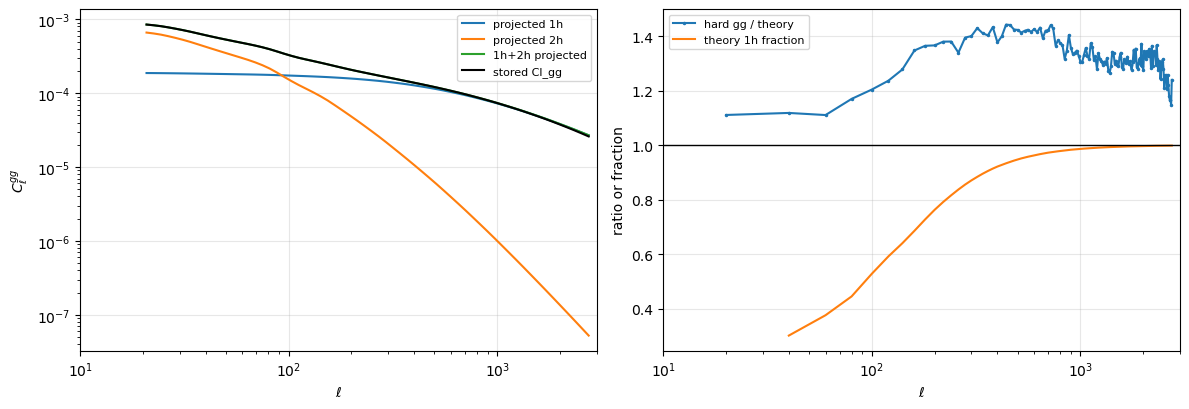

In [14]:
if 'halo_weight_decomp' in globals() and globals().get('halo_weight_decomp_key') == CURRENT_KEY:
    decomp = halo_weight_decomp
else:
    decomp = agh.response_decomposed_pgg_cls(model_ref, COMPARE_BIN)
th = theory_curves[CURRENT_KEY]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
axes[0].plot(decomp['ell'], decomp['gg_1h'], label='projected 1h')
axes[0].plot(decomp['ell'], decomp['gg_2h'], label='projected 2h')
axes[0].plot(decomp['ell'], decomp['gg_sum'], label='1h+2h projected')
axes[0].plot(th['ell'], th['gg'], color='k', lw=1.5, label='stored Cl_gg')
axes[0].set_yscale('log')
axes[0].set_ylabel(r'$C_\ell^{gg}$')
axes[0].legend(fontsize=8)

hard = cls_variants['hard_cut']
th_on_ell = np.interp(hard['ell'], th['ell'], th['gg'], left=np.nan, right=np.nan)
ratio = hard['gg_without_shot'] / th_on_ell
b_ratio = psh.bin_spectrum(hard['ell'], ratio, ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
frac_1h = np.interp(b_ratio['ell'], decomp['ell'], decomp['gg_1h'] / np.maximum(decomp['gg_sum'], 1.0e-30), left=np.nan, right=np.nan)
axes[1].plot(b_ratio['ell'], b_ratio['value'], marker='.', ms=3, label='hard gg / theory')
axes[1].plot(b_ratio['ell'], frac_1h, lw=1.5, label='theory 1h fraction')
axes[1].axhline(1.0, color='k', lw=1.0)
axes[1].set_ylabel('ratio or fraction')
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlim(ELL_MIN, ELL_MAX)
    ax.set_xlabel(r'$\ell$')
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## Pixel-window and shot-noise tests

This checks the estimator mechanics independently of the theory.  A uniform random catalog should give a flat shot-noise autopower, and the shot-subtracted residual should be consistent with zero up to noise.


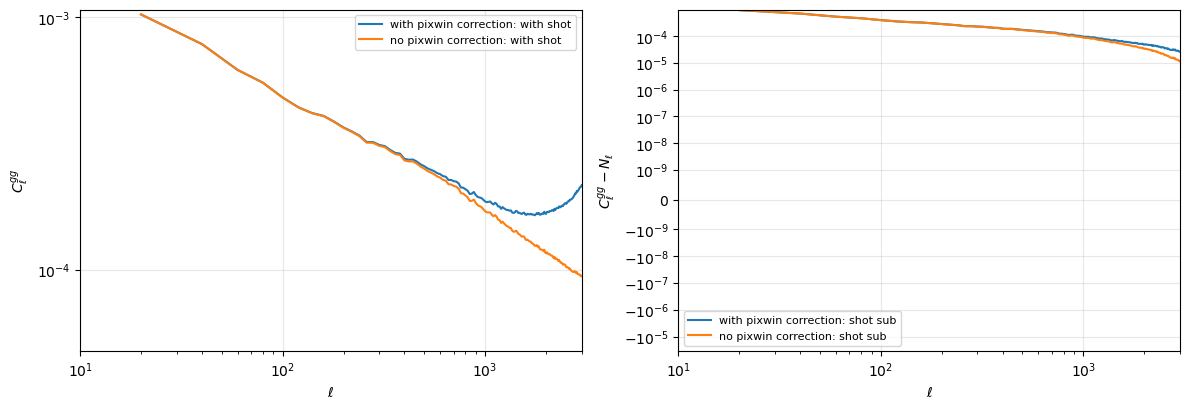

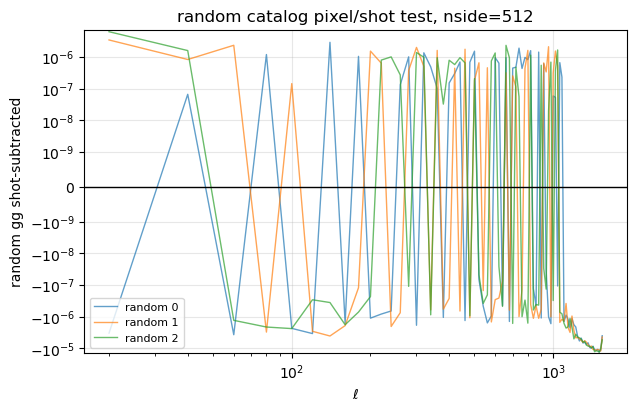

,realization,mean_shot_sub_100_1000,shot,n_gal
0,0,-4.334236e-08,0.000083,152180
1,1,-1.611009e-07,0.000083,152180
2,2,3.216701e-08,0.000083,152180


In [15]:
hard_yes = cls_variants['hard_cut']
hard_no = agh.measure_weighted_cls(maps_pasted, galaxies, NSIDE, z_range=z_range, pixwin_correction=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for name, cls in [('with pixwin correction', hard_yes), ('no pixwin correction', hard_no)]:
    b_with = psh.bin_spectrum(cls['ell'], cls['gg_with_shot'], ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    b_sub = psh.bin_spectrum(cls['ell'], cls['gg_without_shot'], ell_min=ELL_MIN, ell_max=ELL_MAX, delta_ell=DELTA_ELL)
    axes[0].plot(b_with['ell'], b_with['value'], label=f'{name}: with shot')
    axes[1].plot(b_sub['ell'], b_sub['value'], label=f'{name}: shot sub')
for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('symlog', linthresh=1e-9)
    ax.set_xlim(ELL_MIN, ELL_MAX)
    ax.set_xlabel(r'$\ell$')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel(r'$C_\ell^{gg}$')
axes[1].set_ylabel(r'$C_\ell^{gg} - N_\ell$')
fig.tight_layout()
plt.show()

if RUN_RANDOM_PIXEL_TEST:
    rng = np.random.default_rng(24680)
    valid = (galaxies[:, 5] > 0.5) & (galaxies[:, 2] >= z_range[0]) & (galaxies[:, 2] < z_range[1])
    template = galaxies[valid].copy()
    random_rows = []
    fig, ax = plt.subplots(figsize=(7, 4.2))
    for i in range(RANDOM_POISSON_REALIZATIONS):
        rand = template.copy()
        rand[:, 0] = rng.uniform(0.0, 360.0, len(rand))
        rand[:, 1] = np.degrees(np.arcsin(rng.uniform(-1.0, 1.0, len(rand))))
        rand_cls = agh.measure_weighted_cls(maps_pasted, rand, RANDOM_TEST_NSIDE, pixwin_correction=True)
        b = psh.bin_spectrum(rand_cls['ell'], rand_cls['gg_without_shot'], ell_min=ELL_MIN, ell_max=min(3 * RANDOM_TEST_NSIDE - 1, ELL_MAX), delta_ell=DELTA_ELL)
        ax.plot(b['ell'], b['value'], alpha=0.7, lw=1.0, label=f'random {i}')
        mask = (b['ell'] >= 100) & (b['ell'] <= min(1000, 3 * RANDOM_TEST_NSIDE - 1))
        random_rows.append({'realization': i, 'mean_shot_sub_100_1000': float(np.nanmean(b['value'][mask])), 'shot': rand_cls['shot_gg'], 'n_gal': rand_cls['n_gal']})
    ax.axhline(0.0, color='k', lw=1.0)
    ax.set_xscale('log')
    ax.set_yscale('symlog', linthresh=1e-9)
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('random gg shot-subtracted')
    ax.set_title(f'random catalog pixel/shot test, nside={RANDOM_TEST_NSIDE}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()
    display(pd.DataFrame(random_rows))
else:
    print('RUN_RANDOM_PIXEL_TEST=False; skipping random pixel-window test.')


## Compact diagnostic summary

Use this table to decide which failure mode is most likely.  If the top-hat or measured-n(z) theory fixes `gg`, the current comparison was window-mismatched.  If symbolic theory fixes the original Abacus fit reference but not the pasted map, focus on the pasted catalog/HOD realization.  If only small scales remain off and the 1-halo fraction is high, focus on satellites/profile placement.


In [16]:
summary_rows = []
for map_name, theory_name, label in comparison_specs:
    cls = cls_variants[map_name]
    th = theory_curves[theory_name]
    th_on_ell = np.interp(cls['ell'], th['ell'], th['gg'], left=np.nan, right=np.nan)
    ratio = cls['gg_without_shot'] / th_on_ell
    for lo, hi, tag in [(80, 300, 'large/intermediate'), (700, 2500, 'small')]:
        mask = (cls['ell'] >= lo) & (cls['ell'] <= hi) & np.isfinite(ratio)
        summary_rows.append({
            'comparison': label,
            'ell_range': tag,
            'ratio_mean': float(np.nanmean(ratio[mask])) if np.any(mask) else np.nan,
            'ratio_std': float(np.nanstd(ratio[mask])) if np.any(mask) else np.nan,
            'sqrt_ratio_mean': float(np.nanmean(np.sqrt(np.clip(ratio[mask], 0, np.inf)))) if np.any(mask) else np.nan,
        })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print('Read this first:')
print('- If hard-cut/measured-n(z) improves gg relative to fit-n(z), the dominant issue is the comparison window.')
print('- If generated/HOD counts are low or high in the same mass/z bins, the issue is occupation or mass-function matching.')
print('- If satellite projected profiles disagree, focus on profile units/CDF/radius conversion in the galaxy placement path.')
print('- If random catalogs fail to shot-subtract to zero, fix the estimator before interpreting any Cl ratios.')


,comparison,ell_range,ratio_mean,ratio_std,sqrt_ratio_mean
0,hard-cut map / fit n(z) theory,large/intermediate,1.326719,0.143378,1.150125
1,hard-cut map / fit n(z) theory,small,1.321704,0.098665,1.148850
2,hard-cut map / top-hat theory,large/intermediate,1.288188,0.136820,1.133361
3,hard-cut map / top-hat theory,small,1.318346,0.097363,1.147409
4,hard-cut map / measured hard n(z) theory,large/intermediate,1.343202,0.144074,1.157275
5,hard-cut map / measured hard n(z) theory,small,1.355348,0.100311,1.163395
6,fit-n(z) reweighted map / fit theory,large/intermediate,1.303254,0.145253,1.139801
7,fit-n(z) reweighted map / fit theory,small,1.323804,0.096215,1.149804
8,hard-cut map / symbolic fit theory,large/intermediate,1.335093,0.142058,1.153804
9,hard-cut map / symbolic fit theory,small,1.326224,0.099279,1.150808


Read this first:
- If hard-cut/measured-n(z) improves gg relative to fit-n(z), the dominant issue is the comparison window.
- If generated/HOD counts are low or high in the same mass/z bins, the issue is occupation or mass-function matching.
- If satellite projected profiles disagree, focus on profile units/CDF/radius conversion in the galaxy placement path.
- If random catalogs fail to shot-subtract to zero, fix the estimator before interpreting any Cl ratios.
